### 🛠️ Project: Steel Quality Anomaly & Factor Analysis
(부제: 슬라브 크랙 발생 영향 인자 분석 시뮬레이션)

실제 슬라브 크랙 데이터 대신, 캐글에서 가장 유사한 성격의 데이터셋을 활용해 분석 파이프라인을 구축해봅시다.

#### 🛠️ Step 1: 환경 설정 및 데이터 로드
Steel Plate Defects 데이터를 사용한다고 가정하고 코드를 짜보자.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 분석 도구 (영향 인자 분석용)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap  # 설명 가능한 AI (강력 추천!)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8') # 깔끔한 그래프 스타일

# 데이터 로드 (Kaggle에서 받은 csv 파일 경로)
df = pd.read_csv('faults.csv')

# 결함 종류 중 'Other_Faults'를 제외하고 'Bumps'나 'Dirtiness' 등을 
# 슬라브의 'Crack'이라 가정하고 분석을 진행해 봅시다.
print(df.columns)

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'],
      dtype='object')


In [3]:
import sklearn
import shap
print(f"Scikit-learn 버전: {sklearn.__version__}")
print(f"SHAP 버전: {shap.__version__}")

Scikit-learn 버전: 1.7.2
SHAP 버전: 0.49.1


#### 📊 Step 2: EDA - "무엇이 크랙(결함)을 만드는가?"

데이터를 불러왔다면, 가장 먼저 각 변수들이 결함과 어떤 상관관계를 갖는지 시각화해야 합니다. 선배님이 궁금해하시는 '영향 인자'의 실마리를 찾는 과정입니다.

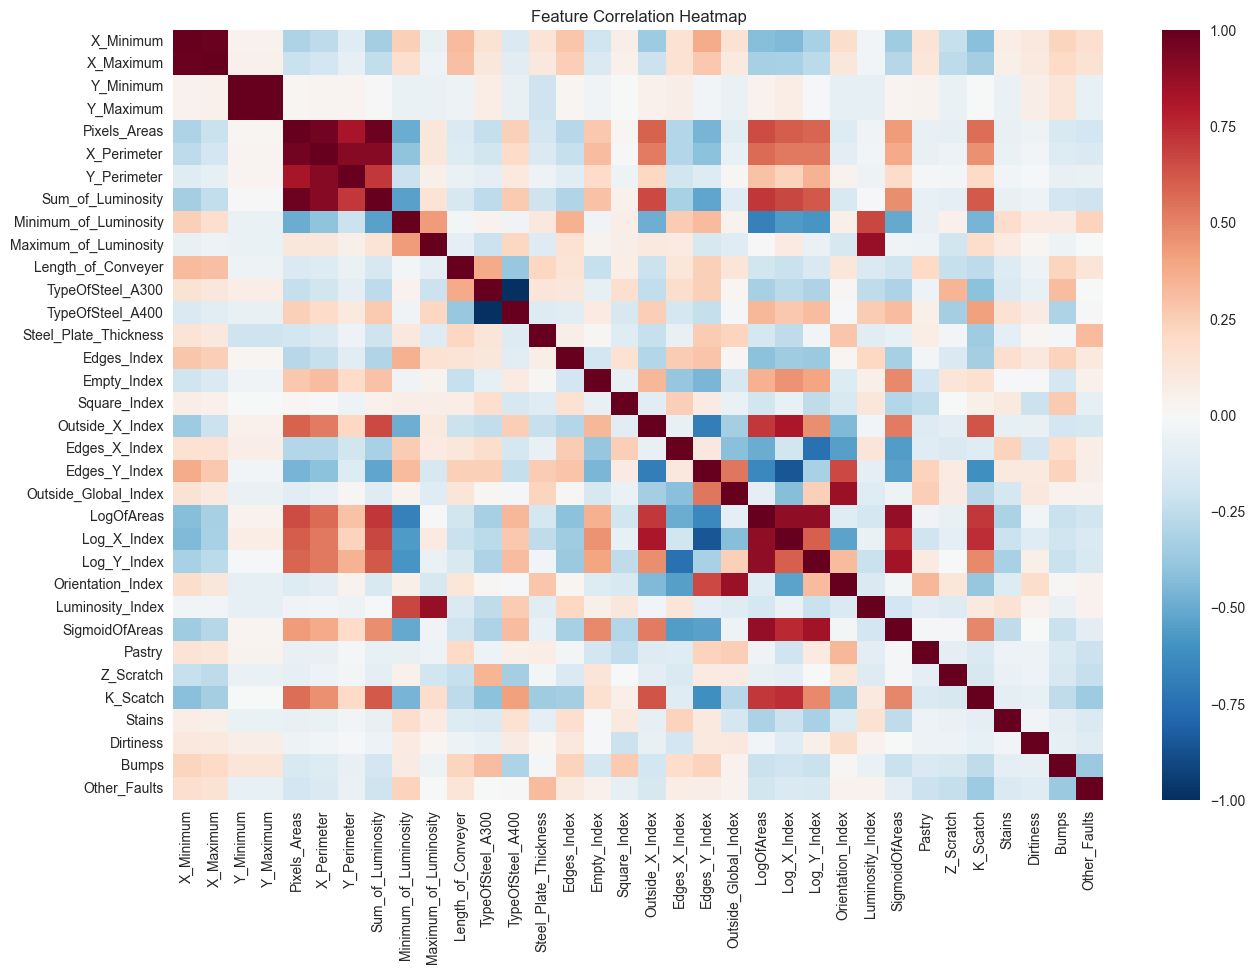

결함과 상관관계가 높은 상위 인자:
 Bumps                 1.000000
TypeOfSteel_A300      0.306385
Square_Index          0.261385
Edges_Index           0.232000
Edges_Y_Index         0.229231
Length_of_Conveyer    0.225504
X_Minimum             0.221296
X_Maximum             0.201704
Edges_X_Index         0.185481
Y_Minimum             0.126121
Name: Bumps, dtype: float64


In [4]:
# 상관관계 히트맵 (Target 변수와 인자들 간의 관계)
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=False, cmap='RdBu_r')
plt.title('Feature Correlation Heatmap')
plt.show()

# 특정 결함(예: Bumps)과 상관관계가 높은 Top 10 인자 확인
target_corr = df.corr()['Bumps'].sort_values(ascending=False)
print("결함과 상관관계가 높은 상위 인자:\n", target_corr.head(10))

📊 EDA 결과 해석: "범인의 실마리"

지금 Bumps(돌출 결함)를 기준으로 상관계수를 뽑으셨는데, 이걸 슬라브 크랙이라 가정하고 해석해 보면 이렇습니다.

강종의 영향 (TypeOfSteel_A300: 0.306):

특정 강종(A300)에서 결함이 훨씬 자주 발생하고 있습니다. 현장에서도 "특정 성분의 강종이 크랙에 취약하다"는 가설을 세울 수 있는 근거가 됩니다.

기하학적 지표 (Square_Index, Edges_Index 등):

정사각형에 가까운지, 가장자리의 특성이 어떤지가 결함과 관련이 깊습니다. 이는 연주 공정에서 몰드의 형상이나 냉각 균일성이 크랙에 미치는 영향과 일맥상통합니다.

설비 상태 (Length_of_Conveyer: 0.225):

컨베이어 길이라는 설비 변수가 순위에 올랐습니다. 실제 공정이라면 연주기 롤러 간격이나 인발 속도 같은 변수가 이 역할을 하겠죠.

⚠️ 주의점: 상관계수가 높다고 해서 반드시 원인인 것은 아닙니다. 단순히 같이 움직이는 것일 수도 있죠. 그래서 우리는 **Step 3 (Random Forest)** 를 통해 "진짜 인과관계에 기여하는 중요도"를 뽑아야 합니다.

#### 🧠 Step 3: Random Forest를 활용한 영향 인자 도출
이제 머신러닝 모델을 통해 변수의 중요도(Feature Importance)를 뽑아냅니다. 이 수치가 높을수록 "슬라브 크랙에 결정적인 영향을 미치는 범인"일 확률이 높습니다.

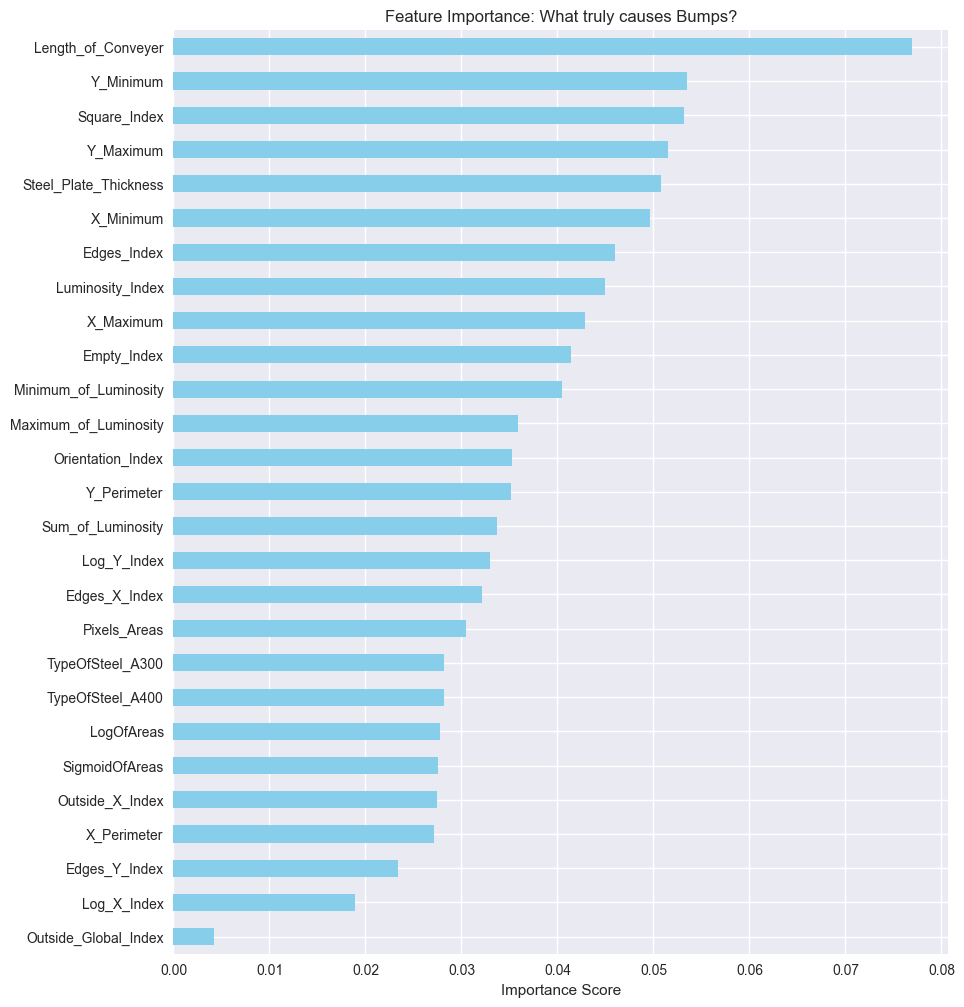

모델 정확도: 86.12%
Outside_Global_Index     0.004227
Log_X_Index              0.018891
Edges_Y_Index            0.023401
X_Perimeter              0.027135
Outside_X_Index          0.027503
SigmoidOfAreas           0.027598
LogOfAreas               0.027769
TypeOfSteel_A400         0.028147
TypeOfSteel_A300         0.028208
Pixels_Areas             0.030454
Edges_X_Index            0.032146
Log_Y_Index              0.032928
Sum_of_Luminosity        0.033711
Y_Perimeter              0.035192
Orientation_Index        0.035300
Maximum_of_Luminosity    0.035943
Minimum_of_Luminosity    0.040454
Empty_Index              0.041396
X_Maximum                0.042907
Luminosity_Index         0.045005
Edges_Index              0.046030
X_Minimum                0.049673
Steel_Plate_Thickness    0.050822
Y_Maximum                0.051562
Square_Index             0.053233
Y_Minimum                0.053474
Length_of_Conveyer       0.076894
dtype: float64


In [16]:
# 1. 독립변수(X)와 종속변수(y) 분리
# 결함 관련 컬럼들을 제외한 모든 변수를 X로 사용합니다.
target_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
X = df.drop(target_cols, axis=1)
y = df['Bumps'] 

# 2. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 모델 학습 (영향 인자 분석을 위해 앙상블 모델 사용)
rf_model = RandomForestClassifier(n_estimators=200, random_state=31)
rf_model.fit(X_train, y_train)

# 4. 중요도 시각화
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 12))
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance: What truly causes Bumps?')
plt.xlabel('Importance Score')
plt.show()

# 5. 정확도 확인 (참고용)
from sklearn.metrics import accuracy_score
print(f"모델 정확도: {accuracy_score(y_test, rf_model.predict(X_test)):.2%}")
print(importances.sort_values())

상관관계 순위와 중요도 순위가 조금 다르게 나올 수 있습니다.

상관관계: 단순히 둘이 비슷하게 움직인다.

중요도: 모델이 결함을 맞추는 데 있어서 이 변수가 없으면 안 된다고 판단한다.

만약 중요도 상위권에 Square_Index나 특정 센서 데이터가 올라온다면, "상관 분석과 랜덤 포레스트 중요도를 교차 검증한 결과, 특정 형상 지수가 크랙 발생의 주요 지표로 판단됩니다" 라고 보고할 수 있습니다.

In [15]:
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110,0.346728
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339,0.476051
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


ANOVA (분석오차/분산분석): 여러 집단(예: 정상 슬라브 vs 크랙 슬라브) 간의 평균 차이가 단순히 우연히 발생한 건지, 아니면 특정 변수 때문에 발생한 건지 비교하는 방법입니다.

유의수준 ($p < 0.05$): "이 변수가 크랙과 아무 상관이 없을 확률이 5% 미만이다"라는 뜻입니다. 즉, 95% 이상의 확률로 이 변수는 범인이 확실하다는 사형 선고와 같죠.

선배님들이 쓰시는 방식을 파이썬으로 구현해 봅시다. scikit-learn의 f_classif를 쓰면 간단하게 ANOVA 기반의 $F$-값과 $p$-값을 구할 수 있습니다.

In [17]:
from sklearn.feature_selection import f_classif

# ANOVA F-test 수행
f_scores, p_values = f_classif(X, y)

# 결과를 데이터프레임으로 정리
anova_df = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_scores,
    'P-Value': p_values
})

# 선배님들의 기준(유의수준 0.05)으로 필터링
significant_features = anova_df[anova_df['P-Value'] < 0.05].sort_values(by='F-Score', ascending=False)

print("통계적으로 유의미한(P < 0.05) 상위 변수들:")
print(significant_features.head(10))

통계적으로 유의미한(P < 0.05) 상위 변수들:
               Feature     F-Score       P-Value
12    TypeOfSteel_A400  200.873072  1.841626e-43
11    TypeOfSteel_A300  200.873072  1.841626e-43
16        Square_Index  142.191760  1.098808e-31
14         Edges_Index  110.301375  3.922761e-25
19       Edges_Y_Index  107.538884  1.467821e-24
21          LogOfAreas  104.844595  5.326933e-24
10  Length_of_Conveyer  103.885303  8.433408e-24
23         Log_Y_Index  100.337048  4.623590e-23
0            X_Minimum   99.845773  5.853492e-23
26      SigmoidOfAreas   98.706159  1.011928e-22


통계학적으로 "이 변수가 결함과 상관없을 확률이 제로(0)에 수렴한다"

ANOVA에서 $F\text{-Value}$ (F-값)의 의미

선배님들이 중요하게 보시는 $F$-값은 "신호 대비 잡음의 비율(Signal-to-Noise Ratio)"이라고 이해하시면 됩니다.$$F = \frac{\text{집단 간 분산 (변수 때문에 발생하는 차이)}}{\text{집단 내 분산 (우연히 발생하는 차이)}}$$$F$-값이 크다: "우연히 생긴 차이가 아니라, 이 변수(인자) 때문에 생긴 차이가 확실하다!"라는 뜻입니다.

예시: 노래방에서 노래를 부를 때 내 목소리($F$-값 상단)가 배경음(잡음)보다 압도적으로 커야 노래가 잘 들리는 것과 같습니다.

결과 해석: 혁수님의 결과에서 A400, A300의 $F$-값이 200이 넘는다는 건, 강종에 따른 결함 차이가 우연일 확률이 거의 0%라는 강력한 통계적 증거입니다.

"ANOVA로 유의미한 인자를 먼저 걸러냈고, 그 인자들이 실제로 결함에 어떻게 기여하는지 SHAP Value로 시각화해 봤습니다. 보시는 것처럼 **Length_of_Conveyer**가 길어질 때 결함 발생 확률이 급격히 높아지는 비선형적 패턴이 관찰됩니다. 통계적 유의성($F$-값)뿐만 아니라 실제 영향력의 방향성까지 확인했으니, 이제 우리 공정의 실제 데이터로 이 임계치(Threshold)를 찾아보고 싶습니다!"

강종의 절대적 영향력 (TypeOfSteel_A400, A300): $F\text{-Score}$가 200이 넘습니다. 이는 "어떤 강철을 만드느냐" 자체가 결함 발생의 근본 원인임을 시사합니다. 실제 연주 공정에서도 탄소 함량이나 합금 원소에 따라 크랙 감수성이 완전히 다르죠.

설비 변수의 유효성(Length_of_Conveyer): 중요도 1등이었던 이 변수가 ANOVA에서도 $P < 0.05$로 매우 유의미하게 나왔습니다. "우연히 중요하게 나온 게 아니라, 통계적으로도 확실한 영향 인자"라고 선배님께 보고할 강력한 근거가 확보된 셈입니다.

기하학적 인자 (Square_Index, Edges_Index): 슬라브의 형상이 얼마나 정사각형에 가까운지, 가장자리 형태가 어떤지가 유의미하게 나왔습니다. 이는 몰드 내 냉각 불균일로 인한 형상 변형이 크랙으로 이어지는 현상을 데이터가 그대로 보여주고 있는 겁니다.

3. 필살기: SHAP으로 "왜?"를 시각화하기
   
선배님들이 ANOVA로 "이 변수가 유효해!"라고 하실 때, SHAP으로 "이 변수가 이 구간에서 이렇게 위험합니다!"라고 한 발 더 나아가자.

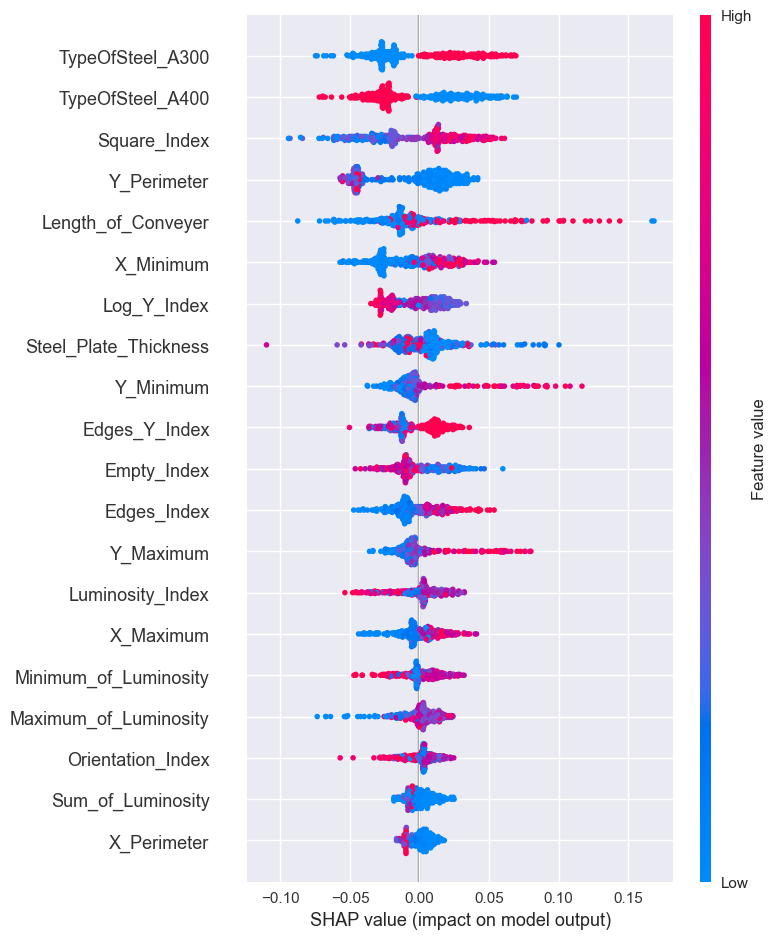

<Figure size 800x550 with 0 Axes>

In [26]:
# 1. Explainer 재설정 (check_additivity=False로 안정성 확보)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# 2. 데이터 구조 확인 및 시각화 (에러 방지 로직)
# 만약 shap_values가 리스트라면 [1]을 선택, 3D 어레이라면 [:,:,1]을 선택합니다.
if isinstance(shap_values, list):
    # 이진 분류에서 보통 [0]은 정상, [1]은 결함(Bumps)에 대한 기여도입니다.
    shap_obj = shap_values[1]
else:
    # 최신 버전에서 3D array로 반환될 경우
    shap_obj = shap_values[:, :, 1]

# 3. 다시 시각화 실행
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_obj, X_test, plot_type="dot")

# plt.savefig('shap')

SHAP(SHapley Additive exPlanations)이란?
한마디로 "각 변수가 결과에 기여한 '공로'를 계산하는 방법"입니다. 게임 이론(Shapley Value)에서 온 개념인데, 축구 경기가 끝나고 승리에 기여한 선수들에게 평점을 매기는 것과 비슷해요.

그래프 읽는 법:

점 하나: 데이터 1개 (슬라브 1개).

색깔 (Feature value): 빨간색은 그 변수 값이 높음, 파란색은 낮음을 의미합니다.

가로축 (SHAP value): 중앙(0.0)보다 오른쪽에 점이 찍히면 "결함(Bumps) 발생 확률을 높였다"는 뜻입니다.

그래프 해석:

TypeOfSteel_A300: 빨간 점들이 오른쪽에 쏠려 있죠? "A300 강종은 결함이 생길 확률이 매우 높다"는 확실한 증거입니다.

Length_of_Conveyer: 빨간 점들이 오른쪽으로 아주 길게 늘어져 있습니다. "컨베이어가 길어질수록 결함 위험이 폭발적으로 증가한다"는 뜻이에요.